# Correlations

In [140]:
import pickle
import torch
import pandas as pd
import numpy as np

from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

from escapecalculator import EscapeCalculator    
    # from https://github.com/jbloomlab/SARS2-RBD-escape-calc/blob/main/escapecalculator.py
    # https://jbloomlab.github.io/SARS2-RBD-escape-calc/escapecalculator.html
    # https://jbloomlab.github.io/SARS2-RBD-escape-calc/
calculator = EscapeCalculator()

## Read in data

In [25]:
def get_position(mutation):
    pos = [_ for _ in mutation if _.isdigit()]
    pos = ''.join(pos)
    pos = int(pos)
    return pos

In [27]:
# Infectivity
infectivity_file = 'results/mutation_infectivity_effects.csv'
infectivity = pd.read_csv(infectivity_file)
infectivity['Position'] = infectivity['Mutation'].apply(lambda x: get_position(x))

In [28]:
# Neutralization
neutralization_file = 'results/Pooled Mutation Effect/mutation_neutralization_effects_cross_pool.csv'
neutralization = pd.read_csv(neutralization_file)
neutralization = neutralization.rename(columns={'Mean': 'Mean (Log)', 'Std':'Std (Log)'})
neutralization['Mean'] = neutralization['Mean (Log)'].apply(np.exp)
neutralization['Position'] = neutralization['Mutation'].apply(lambda x: get_position(x))

In [29]:
# PyR0
pyro_file = 'data/PyR0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])
pyro['Position'] = pyro['Mutation'].apply(lambda x: get_position(x))

In [30]:
# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])
bvas['Position'] = bvas['Mutation'].apply(lambda x: get_position(x))

In [32]:
# DMS - https://github.com/jbloomlab/SARS-CoV-2-RBD_DMS/blob/14a3beb05df714e9881685871852b825d79d1b9c/results/single_mut_effects/single_mut_effects.csv#L2
filename = 'data/Bloom/single_mut_effects.txt'
columns = {#'site_SARS2':'position', 
           'mutation':'Mutation', 
           'bind_avg':'ACE2 Binding', 
           'expr_avg':'Expression'}
dms = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)
dms['Position'] = dms['Mutation'].apply(lambda x: get_position(x))

In [13]:
# Bloom & Neher Fitness - https://raw.githubusercontent.com/jbloomlab/SARS2-mut-fitness/main/results_public_2023-10-01/aa_fitness/aamut_fitness_all.csv
filename = 'data/Bloom/aamut_fitness_all.csv'
columns = {'gene':'Gene',
           'aa_site': 'Position',
           'aa_mutation': 'Mutation',
           'delta_fitness': 'Bloom Fitness'}
bloom = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns)
bloom = bloom[bloom['Gene'] == 'S'].sort_values(by='Position').reset_index(drop=True)

In [14]:
# EVE and EVEscape - Data S4 https://www.biorxiv.org/content/10.1101/2022.07.21.501023v1.supplementary-material?versioned=true
# download here: https://www.biorxiv.org/content/biorxiv/early/2022/07/22/2022.07.21.501023/DC5/embed/media-5.zip?download=true
filename = 'data/EVEscape/spike_evescape_predictions.csv'
columns = {'i':'Position', 
           'wt':'wt',
           'mut':'mut',
           'evescape':'EVEscape',
           'eve':'EVE'}
evescape = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns).sort_values(by='Position').reset_index(drop=True)
evescape['Mutation'] = evescape['wt'].astype(str) + evescape['Position'].astype(str) + evescape['mut'].astype(str)

In [15]:
# Predicted Escape, data aggregated in evescape paper (cited above)
filename = 'data/EVEscape/spike_evescape_predictions.csv'
columns = {'i':'Position', 
           'wt':'wt',
           'mut':'mut',
           'max_escape_bloom':'Bloom - Max Escape',
           'max_escape_xie':'Xie - Max Escape'}
escape = pd.read_csv(filename, usecols=columns.keys()).rename(columns=columns).sort_values(by='Position').reset_index(drop=True)
escape['Mutation'] = escape['wt'].astype(str) + evescape['Position'].astype(str) + evescape['mut'].astype(str)

In [145]:
# Infectivity calculated escape from Bloom Calculator 
positions = infectivity['Position'].tolist()
calc_inf = calculator.escape_per_site([]).query('site in @positions').reset_index(drop=True)
calc_inf = calc_inf.rename(columns={'site':'Position'}).drop(columns=['original_escape'])

In [146]:
# Neutralization calculated escape from Bloom Calculator 
positions = neutralization['Position'].tolist()
calc_neut = calculator.escape_per_site([]).query('site in @positions').reset_index(drop=True)
calc_neut = calc_neut.rename(columns={'site':'Position'}).drop(columns=['original_escape'])

## Heatmap all options

C:\Users\blk18\AppData\Local\Temp\ipykernel_25732\451403842.py:6: FutureWarning: Passing 'suffixes' which cause duplicate columns {'Position_x'} in the result is deprecated and will raise a MergeError in a future version.
  pd.merge(
C:\Users\blk18\AppData\Local\Temp\ipykernel_25732\451403842.py:4: FutureWarning: Passing 'suffixes' which cause duplicate columns {'Position_x'} in the result is deprecated and will raise a MergeError in a future version.
  pd.merge(
C:\Users\blk18\AppData\Local\Temp\ipykernel_25732\451403842.py:14: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  calc_neut, on='Position').dropna().corr()[['Mean (Log)']]
C:\Users\blk18\AppData\Local\Temp\ipykernel_25732\451403842.py:21: FutureWarning: Passing 'suffixes' which cause duplicate columns {'Position_x'} in the result is deprecated and will raise

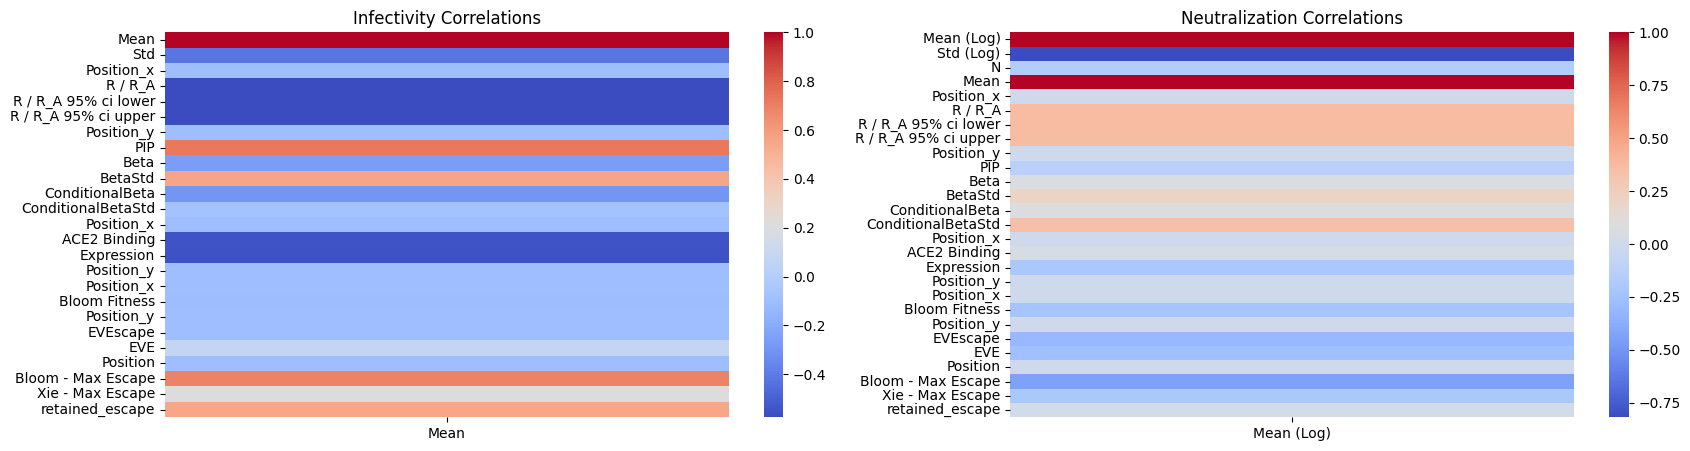

In [147]:
neut_data = \
    pd.merge(
        pd.merge(
            pd.merge(
                pd.merge(
                    pd.merge(
                        pd.merge(
                            pd.merge(neutralization, pyro, on='Mutation'),
                            bvas, on='Mutation'),
                        dms, on='Mutation'),
                    bloom, on='Mutation'),
                evescape, on='Mutation'),
            escape, on='Mutation'),
    calc_neut, on='Position').dropna().corr()[['Mean (Log)']]

inf_data = \
    pd.merge(
        pd.merge(
            pd.merge(
                pd.merge(
                    pd.merge(
                        pd.merge(
                            pd.merge(infectivity, pyro, on='Mutation'),
                            bvas, on='Mutation'),
                        dms, on='Mutation'),
                    bloom, on='Mutation'),
                evescape, on='Mutation'),
            escape, on='Mutation'),
    calc_inf, on='Position').dropna().corr()[['Mean']]


fig, axes = plt.subplots(1,2, figsize=(20,5))

ax = axes[0]
sns.heatmap(data=inf_data, ax=ax, cmap="coolwarm")
ytick_labels = inf_data.index.tolist();
ax.set_yticks([i + 0.5 for i in range(len(ytick_labels))], ytick_labels);
ax.set_title('Infectivity Correlations');

ax = axes[1]
sns.heatmap(data=neut_data, ax=ax, cmap="coolwarm")
ytick_labels = neut_data.index.tolist();
ax.set_yticks([i + 0.5 for i in range(len(ytick_labels))], ytick_labels);
ax.set_title('Neutralization Correlations');

I'll need to try this again using updated pyro numbers. I have a feeling there are errors in the PyR0 / BVAS estimates.

## Build Plotter

In [204]:
def corr(x, y, df):
    series1 = df[[x,y]].dropna()[x]
    series2 = df[[x,y]].dropna()[y]
    R, p = pearsonr(series1, series2)
    return R, p

def annotate(ax, x, y, df, t, n=20):
    if len(df[[x,y,t]].dropna()) <= n:
        # Label all points
        for label in df[t].dropna():
            xi = df[x][df[t]==label].item()
            yi = df[y][df[t]==label].item()
            if not pd.isna(xi) and not pd.isna(yi):
                ax.text(xi, yi, label, rotation=20, fontsize=7)
                
    else:
        # grab at most n outliers and label
        labels = df.sort_values(by=x).head(int(n/4))[t].tolist() + \
                 df.sort_values(by=x).tail(int(n/4))[t].tolist() + \
                 df.sort_values(by=y).head(int(n/4))[t].tolist() + \
                 df.sort_values(by=y).tail(int(n/4))[t].tolist()
        for label in labels:
            xi = df[x][df[t]==label].item()
            yi = df[y][df[t]==label].item()
            if not pd.isna(xi) and not pd.isna(yi):
                ax.text(xi, yi, label, rotation=20, fontsize=7)

def plot(x, y, df, t=None, logistic=False, **kwargs):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for ax in axes:
        x, y = y, x
        R, p = corr(x,y,df)
        sns.regplot(x=x,
                    y=y,
                    data=df,
                    label='R={:.2f}\np={:.2e}'.format(R,p),
                    logistic=logistic,
                    ax=ax);
        ax.legend()

        # Annotate muts
        if t:
            annotate(ax, x, y, df, t, **kwargs)

        ax.set_title(f'{x} vs. {y} on {len(df[[x,y]].drop_duplicates())} mutations');

## Explore relationships

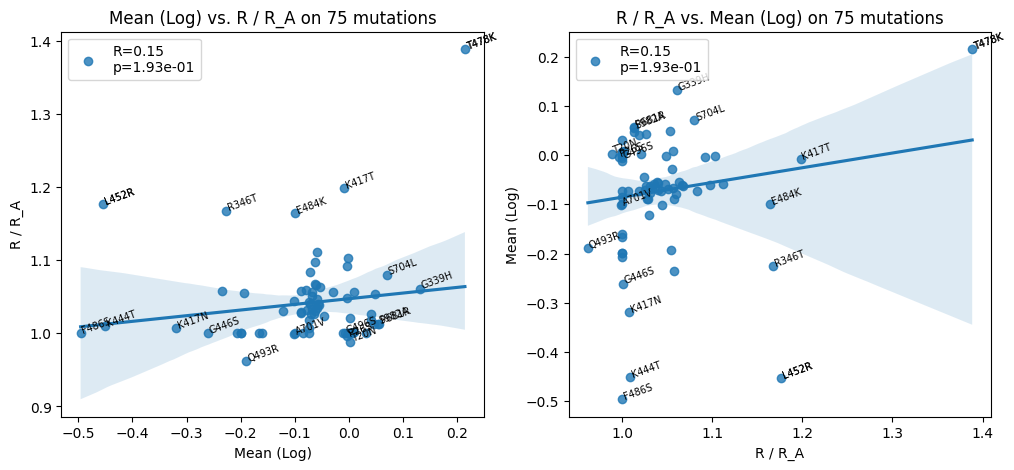

In [205]:
# PyR0 vs Neutralization
data = pd.merge(pyro, neutralization, on='Mutation')
plot('R / R_A', 'Mean (Log)', data, t='Mutation');

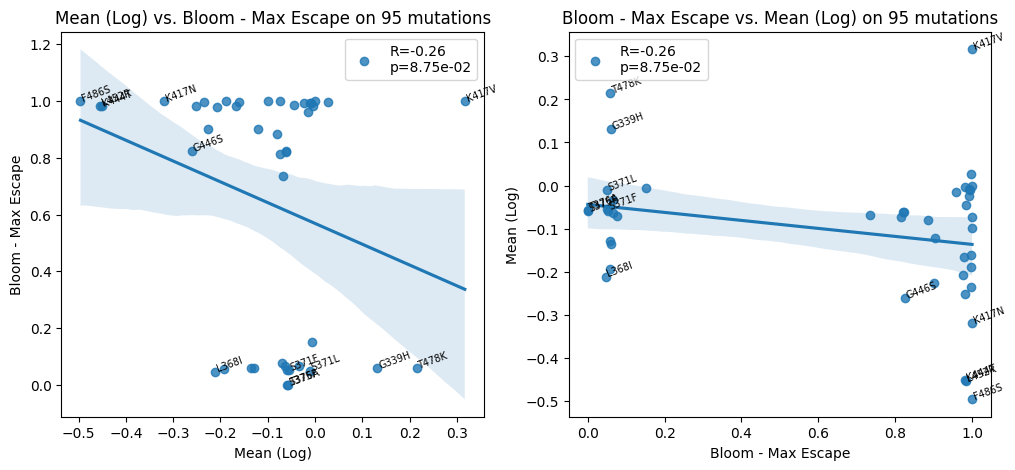

In [206]:
# Bloom Max Escape vs Neutralization
data = pd.merge(escape, neutralization, on='Mutation')
plot('Bloom - Max Escape', 'Mean (Log)', data, t='Mutation');

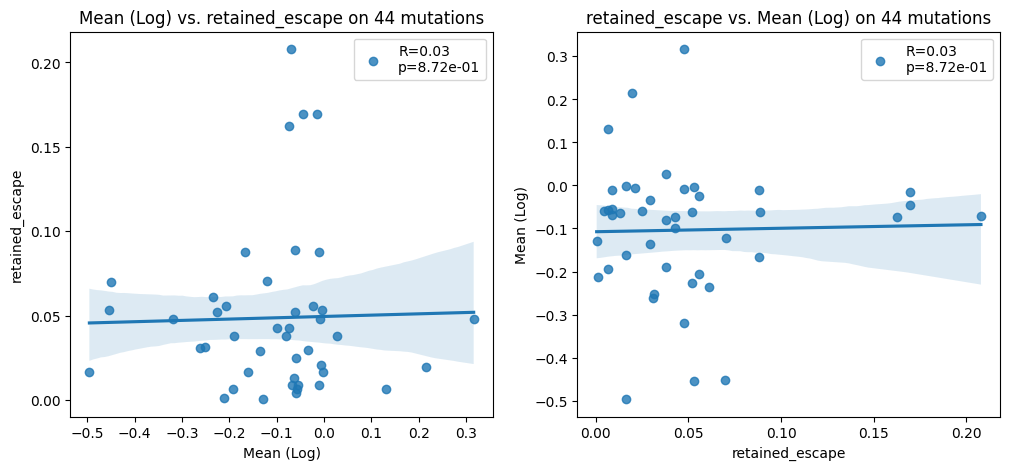

In [213]:
data = pd.merge(calc_neut, neutralization, on='Position')
corr('retained_escape', 'Mean (Log)', data)
plot('retained_escape', 'Mean (Log)', data);